In [6]:
# ============================================================
import os
import gc
import re
import math
import json
import random
from pathlib import Path
from contextlib import nullcontext

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)


PyTorch: 2.10.0+cu128


In [19]:
# ============================================================
DATASET_TAG = "desync100"       # "fixed", "desync50", or "desync100"
ASCAD_PATH_OVERRIDE = None      # example: "/kaggle/input/.../ASCAD_desync50.h5"

RUN_MODE = "standard"          # "debug", "standard", or "final"
RESUME = True

SEED = 42
TARGET_BYTE = 2                 # ASCAD target byte used in the uploaded TransNet code

# Architecture/training mode.
MODEL_FAMILY = "hdt"            # Hierarchical Desync Transformer
NORM_MODE = "global"            # "global", "none", or "trace"

# No heavy shift augmentation. The ASCAD desync files are already desynchronised.
# If the model starts learning but plateaus, try 2 for desync50 and 4 for desync100.
AUG_SHIFT = 0
AUG_NOISE_STD = 0.0
AUG_AMP_STD = 0.02
AUG_OFFSET_STD = 0.01

# Effective batch 256 by default. Lower TRAIN_BATCH_SIZE if OOM and increase GRAD_ACCUM_STEPS.
TRAIN_BATCH_SIZE = 128
GRAD_ACCUM_STEPS = 2
EFFECTIVE_BATCH_SIZE = TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS
EVAL_BATCH_SIZE = 128

# Dataloader workers: 0 is slower but stable in notebooks.
NUM_WORKERS = 0

if RUN_MODE == "debug":
    TRAIN_STEPS = 1000
    SAVE_EVERY_STEPS = 500
    LR_DECAY_STEPS = 12000 if DATASET_TAG != "desync100" else 16000
    N_RANK_REPEATS = 5
    ATTACK_TRACES_FOR_GE = 3000
elif RUN_MODE == "standard":
    TRAIN_STEPS = 20000 if DATASET_TAG != "desync100" else 100000
    SAVE_EVERY_STEPS = 2000
    LR_DECAY_STEPS = 100000
    N_RANK_REPEATS = 30
    ATTACK_TRACES_FOR_GE = 5000
elif RUN_MODE == "final":
    TRAIN_STEPS = 24000 if DATASET_TAG != "desync100" else 32000
    SAVE_EVERY_STEPS = 4000
    LR_DECAY_STEPS = TRAIN_STEPS
    N_RANK_REPEATS = 100
    ATTACK_TRACES_FOR_GE = 10000
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

# Optimisation.
LR = 8e-4
MIN_LR_RATIO = 0.03
WARMUP_STEPS = 500 if RUN_MODE != "debug" else 100
WEIGHT_DECAY = 2e-4
GRAD_CLIP = 1.0
USE_AMP_REQUESTED = True

# Model dimensions.
D_MODEL = 128
N_HEAD = 4
D_FF = 384
DROPOUT = 0.10
ATTN_DROPOUT = 0.08
WINDOW_SIZE = 50
HIGHRES_WINDOW_BLOCKS = 2
MID_WINDOW_BLOCKS = 1
GLOBAL_BLOCKS = 2
POOL_QUERIES = 4

# Auxiliary leakage heads. Keep modest; the final attack still uses 256-class logits.
HW_AUX_WEIGHT = 0.20
BIT_AUX_WEIGHT = 0.05

MODEL_TAG = (
    f"hdt_{DATASET_TAG}_{RUN_MODE}_"
    f"d{D_MODEL}_w{WINDOW_SIZE}_bs{TRAIN_BATCH_SIZE}x{GRAD_ACCUM_STEPS}_"
    f"norm-{NORM_MODE}_aug{AUG_SHIFT}"
)

print("DATASET_TAG:", DATASET_TAG)
print("RUN_MODE:", RUN_MODE)
print("MODEL_TAG:", MODEL_TAG)
print("TRAIN_STEPS:", TRAIN_STEPS)
print("SAVE_EVERY_STEPS:", SAVE_EVERY_STEPS)
print("LR_DECAY_STEPS:", LR_DECAY_STEPS)
print("TRAIN_BATCH_SIZE:", TRAIN_BATCH_SIZE)
print("GRAD_ACCUM_STEPS:", GRAD_ACCUM_STEPS)
print("EFFECTIVE_BATCH_SIZE:", EFFECTIVE_BATCH_SIZE)
print("NORM_MODE:", NORM_MODE)
print("AUG_SHIFT:", AUG_SHIFT)
print("USE_AMP_REQUESTED:", USE_AMP_REQUESTED)
print("RESUME:", RESUME)


DATASET_TAG: desync100
RUN_MODE: standard
MODEL_TAG: hdt_desync100_standard_d128_w50_bs128x2_norm-global_aug0
TRAIN_STEPS: 100000
SAVE_EVERY_STEPS: 2000
LR_DECAY_STEPS: 100000
TRAIN_BATCH_SIZE: 128
GRAD_ACCUM_STEPS: 2
EFFECTIVE_BATCH_SIZE: 256
NORM_MODE: global
AUG_SHIFT: 0
USE_AMP_REQUESTED: True
RESUME: True


In [20]:
# ============================================================
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(USE_AMP_REQUESTED and torch.cuda.is_available())
AMP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)
print("USE_AMP:", USE_AMP)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)


DEVICE: cuda
USE_AMP: True
GPU: Tesla T4
GPU memory GB: 14.56219482421875


In [21]:
# ============================================================
SBOX = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16
], dtype=np.uint8)

HW_TABLE = np.array([bin(i).count("1") for i in range(256)], dtype=np.int64)
BIT_TABLE = np.array([[(i >> b) & 1 for b in range(8)] for i in range(256)], dtype=np.float32)

print("SBOX length:", len(SBOX))


SBOX length: 256


In [22]:
# ============================================================
def normalize_path_text(path):
    return str(path).lower().replace("_", "").replace("-", "").replace(" ", "")


def inspect_h5_candidate(path):
    try:
        with h5py.File(path, "r") as f:
            if "Profiling_traces" not in f or "Attack_traces" not in f:
                return None
            if "traces" not in f["Profiling_traces"] or "labels" not in f["Profiling_traces"]:
                return None
            if "traces" not in f["Attack_traces"] or "labels" not in f["Attack_traces"]:
                return None
            return {
                "path": str(path),
                "prof_shape": tuple(f["Profiling_traces/traces"].shape),
                "atk_shape": tuple(f["Attack_traces/traces"].shape),
                "has_meta": "metadata" in f["Profiling_traces"] and "metadata" in f["Attack_traces"],
            }
    except Exception:
        return None


def choose_ascad_path():
    if ASCAD_PATH_OVERRIDE is not None:
        path = Path(ASCAD_PATH_OVERRIDE)
        if not path.exists():
            raise FileNotFoundError(path)
        return str(path)

    search_roots = [Path("/kaggle/input"), Path("/mnt/data"), Path(".")]
    h5_files = []
    for root in search_roots:
        if root.exists():
            h5_files.extend(list(root.rglob("*.h5")))

    if len(h5_files) == 0:
        raise FileNotFoundError("No .h5 files found. Set ASCAD_PATH_OVERRIDE.")

    if DATASET_TAG == "fixed":
        wanted = [p for p in h5_files if "desync" not in normalize_path_text(p)]
    else:
        wanted = [p for p in h5_files if DATASET_TAG.lower() in normalize_path_text(p)]

    candidates = []
    for p in wanted:
        info = inspect_h5_candidate(p)
        if info is not None:
            candidates.append(info)

    if len(candidates) == 0:
        print("Found H5 files:")
        for p in h5_files:
            print(" -", p)
        raise FileNotFoundError(f"No ASCAD-like H5 matched DATASET_TAG={DATASET_TAG}")

    # Prefer canonical 50000 x 700 / 10000 x 700 files.
    def score(c):
        s = 0
        if c["prof_shape"] == (50000, 700): s -= 100
        if c["atk_shape"] == (10000, 700): s -= 100
        if c["has_meta"]: s -= 20
        return s

    candidates = sorted(candidates, key=score)
    print("Matching candidates:")
    for c in candidates:
        print(c)
    return candidates[0]["path"]


ASCAD_PATH = choose_ascad_path()
print("Using ASCAD_PATH:", ASCAD_PATH)

with h5py.File(ASCAD_PATH, "r") as f:
    X_prof = f["Profiling_traces/traces"][:].astype(np.float32)
    y_prof = f["Profiling_traces/labels"][:].astype(np.int64)
    meta_prof = f["Profiling_traces/metadata"][:]

    X_attack = f["Attack_traces/traces"][:].astype(np.float32)
    y_attack = f["Attack_traces/labels"][:].astype(np.int64)
    meta_attack = f["Attack_traces/metadata"][:]

print("X_prof:", X_prof.shape, X_prof.dtype, X_prof.min(), X_prof.max(), X_prof.mean(), X_prof.std())
print("X_attack:", X_attack.shape, X_attack.dtype, X_attack.min(), X_attack.max(), X_attack.mean(), X_attack.std())
print("y_prof:", y_prof.shape, "unique:", len(np.unique(y_prof)))
print("metadata fields:", meta_prof.dtype.names)


Matching candidates:
{'path': '/kaggle/input/datasets/govindgopakumar/ascad-dataset/ASCAD_data/ASCAD_databases/ASCAD_desync100.h5', 'prof_shape': (50000, 700), 'atk_shape': (10000, 700), 'has_meta': True}
Using ASCAD_PATH: /kaggle/input/datasets/govindgopakumar/ascad-dataset/ASCAD_data/ASCAD_databases/ASCAD_desync100.h5
X_prof: (50000, 700) float32 -66.0 47.0 -11.099548 26.114227
X_attack: (10000, 700) float32 -67.0 46.0 -11.061205 26.117954
y_prof: (50000,) unique: 256
metadata fields: ('plaintext', 'ciphertext', 'key', 'masks', 'desync')


In [23]:
# ============================================================
prof_plain = meta_prof["plaintext"][:, TARGET_BYTE].astype(np.uint8)
prof_key = meta_prof["key"][:, TARGET_BYTE].astype(np.uint8)
attack_plain = meta_attack["plaintext"][:, TARGET_BYTE].astype(np.uint8)
attack_key = meta_attack["key"][:, TARGET_BYTE].astype(np.uint8)

prof_expected = SBOX[np.bitwise_xor(prof_plain, prof_key)].astype(np.int64)
attack_expected = SBOX[np.bitwise_xor(attack_plain, attack_key)].astype(np.int64)

prof_match = float(np.mean(prof_expected == y_prof))
attack_match = float(np.mean(attack_expected == y_attack))
ATTACK_TRUE_KEY = int(attack_key[0])
attack_key_constant = bool(np.all(attack_key == ATTACK_TRUE_KEY))

print("Profiling label match:", prof_match)
print("Attack label match:", attack_match)
print("Attack true key:", ATTACK_TRUE_KEY)
print("Attack key constant:", attack_key_constant)

if prof_match < 0.999 or attack_match < 0.999:
    raise RuntimeError("Labels do not match SBOX[plaintext_byte xor key_byte]. Check TARGET_BYTE/dataset.")
if not attack_key_constant:
    raise RuntimeError("Attack target key is not constant; rank/GE would be invalid.")

label_counts = np.bincount(y_prof, minlength=256)
print("Label count min/max/mean:", label_counts.min(), label_counts.max(), label_counts.mean())
print("Random CE ln(256):", np.log(256.0))
print("Random accuracy:", 1/256)


Profiling label match: 1.0
Attack label match: 1.0
Attack true key: 224
Attack key constant: True
Label count min/max/mean: 154 244 195.3125
Random CE ln(256): 5.545177444479562
Random accuracy: 0.00390625


In [24]:
# ============================================================
if NORM_MODE == "global":
    norm_mean = np.array([X_prof.mean()], dtype=np.float32)
    norm_std = np.array([max(X_prof.std(), 1e-6)], dtype=np.float32)
elif NORM_MODE == "none":
    norm_mean = np.array([0.0], dtype=np.float32)
    norm_std = np.array([1.0], dtype=np.float32)
elif NORM_MODE == "trace":
    norm_mean = np.array([0.0], dtype=np.float32)
    norm_std = np.array([1.0], dtype=np.float32)
else:
    raise ValueError(f"Unknown NORM_MODE: {NORM_MODE}")

print("norm_mean:", norm_mean, "norm_std:", norm_std)


class ASCADTraceDataset(Dataset):
    def __init__(self, traces, labels, train=False):
        self.traces = traces.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.train = bool(train)

    def __len__(self):
        return len(self.traces)

    @staticmethod
    def shift_zero(x, shift):
        if shift == 0:
            return x
        y = np.zeros_like(x)
        if shift > 0:
            y[shift:] = x[:-shift]
        else:
            y[:shift] = x[-shift:]
        return y

    def normalise(self, x):
        if NORM_MODE == "global":
            x = (x - norm_mean[0]) / norm_std[0]
        elif NORM_MODE == "trace":
            x = (x - x.mean()) / max(x.std(), 1e-6)
        return x

    def __getitem__(self, idx):
        x = self.traces[idx].astype(np.float32)
        x = self.normalise(x)

        if self.train:
            if AUG_SHIFT > 0:
                shift = np.random.randint(-AUG_SHIFT, AUG_SHIFT + 1)
                x = self.shift_zero(x, shift)
            if AUG_AMP_STD > 0:
                x = x * np.float32(1.0 + np.random.normal(0.0, AUG_AMP_STD))
            if AUG_OFFSET_STD > 0:
                x = x + np.float32(np.random.normal(0.0, AUG_OFFSET_STD))
            if AUG_NOISE_STD > 0:
                x = x + np.random.normal(0.0, AUG_NOISE_STD, size=x.shape).astype(np.float32)

        y = int(self.labels[idx])
        hw = int(HW_TABLE[y])
        bits = BIT_TABLE[y]
        return (
            torch.from_numpy(x.astype(np.float32)),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(hw, dtype=torch.long),
            torch.from_numpy(bits.astype(np.float32)),
        )


train_ds = ASCADTraceDataset(X_prof, y_prof, train=True)
attack_ds = ASCADTraceDataset(X_attack, y_attack, train=False)

loader_kwargs = dict(
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

train_loader = DataLoader(
    train_ds,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    **loader_kwargs,
)

attack_loader = DataLoader(
    attack_ds,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)

print("Train batches:", len(train_loader))
print("Attack batches:", len(attack_loader))
xb, yb, hwb, bitb = next(iter(train_loader))
print("Batch:", xb.shape, yb.shape, hwb.shape, bitb.shape)
print("Batch trace mean/std:", float(xb.mean()), float(xb.std()))


norm_mean: [-11.099548] norm_std: [26.114227]
Train batches: 390
Attack batches: 79
Batch: torch.Size([128, 700]) torch.Size([128]) torch.Size([128]) torch.Size([128, 8])
Batch trace mean/std: 0.0029629652854055166 0.9994333386421204


In [25]:
# ============================================================
def stable_log_softmax_np(logits):
    z = logits.astype(np.float64)
    z = z - z.max(axis=1, keepdims=True)
    return z - np.log(np.exp(z).sum(axis=1, keepdims=True))


def rank_curve_from_log_probs(log_probs, plaintexts, true_key):
    key_scores = np.zeros(256, dtype=np.float64)
    ranks = np.zeros(len(log_probs), dtype=np.int64)
    key_candidates = np.arange(256, dtype=np.uint8)

    for i in range(len(log_probs)):
        pt = np.uint8(plaintexts[i])
        hyp_labels = SBOX[np.bitwise_xor(pt, key_candidates)]
        key_scores += log_probs[i, hyp_labels]
        true_score = key_scores[int(true_key)]
        ranks[i] = int(np.sum(key_scores > true_score))

    return ranks


def make_ge_indices(n_items, n_traces, n_repeats, seed):
    rng = np.random.default_rng(seed)
    n_traces = min(int(n_traces), int(n_items))
    return [rng.permutation(n_items)[:n_traces] for _ in range(int(n_repeats))]


def guessing_entropy_from_log_probs(log_probs, plaintexts, true_key, n_traces, n_repeats, seed):
    indices = make_ge_indices(len(log_probs), n_traces, n_repeats, seed)
    curves = []
    for idx in tqdm(indices, desc="GE repeats", leave=False):
        curve = rank_curve_from_log_probs(log_probs[idx], plaintexts[idx], true_key)
        curves.append(curve)
    curves = np.stack(curves, axis=0)
    return curves.mean(axis=0), curves.std(axis=0), curves


def metrics_from_ge(single_curve, ge_mean):
    if np.any(ge_mean < 1.0):
        t_ge = int(np.argmax(ge_mean < 1.0) + 1)
    else:
        t_ge = None
    if np.any(single_curve == 0):
        t_rank0 = int(np.argmax(single_curve == 0) + 1)
    else:
        t_rank0 = None
    return {
        "single_final_rank": int(single_curve[-1]),
        "single_min_rank": int(single_curve.min()),
        "single_traces_to_rank0": t_rank0,
        "ge_final": float(ge_mean[-1]),
        "ge_min": float(ge_mean.min()),
        "traces_to_ge_below_1": t_ge,
    }


In [26]:
# ============================================================
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))
        self.eps = eps
    def forward(self, x):
        dtype = x.dtype
        y = x.float()
        y = y * torch.rsqrt(y.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return (y.to(dtype) * self.weight)


class MultiScaleStem(nn.Module):
    def __init__(self, in_ch=3, d_model=128, dropout=0.05):
        super().__init__()
        branch = d_model // 4
        self.branches = nn.ModuleList([
            nn.Conv1d(in_ch, branch, kernel_size=7, padding=3, bias=False),
            nn.Conv1d(in_ch, branch, kernel_size=15, padding=7, bias=False),
            nn.Conv1d(in_ch, branch, kernel_size=31, padding=15, bias=False),
            nn.Conv1d(in_ch, branch, kernel_size=51, padding=25, bias=False),
        ])
        self.fuse = nn.Sequential(
            nn.GroupNorm(8, branch * 4),
            nn.GELU(),
            nn.Conv1d(branch * 4, d_model, kernel_size=1, bias=False),
            nn.GroupNorm(8, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        x = torch.cat([b(x) for b in self.branches], dim=1)
        return self.fuse(x)


class ResidualDWConvBlock(nn.Module):
    def __init__(self, channels, kernel_size=15, dilation=1, dropout=0.05, expansion=2):
        super().__init__()
        padding = (kernel_size // 2) * dilation
        hidden = channels * expansion
        self.net = nn.Sequential(
            nn.GroupNorm(8, channels),
            nn.Conv1d(channels, hidden, kernel_size=1, bias=False),
            nn.GELU(),
            nn.Conv1d(hidden, hidden, kernel_size=kernel_size, padding=padding,
                      dilation=dilation, groups=hidden, bias=False),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1, bias=False),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return x + self.net(x)


class DownsampleTokens(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.conv = nn.Conv1d(dim, dim, kernel_size=5, stride=2, padding=2, bias=False)
        self.norm = nn.GroupNorm(8, dim)
        self.act = nn.GELU()
    def forward(self, x):
        # [B, L, D] -> [B, ceil(L/2), D]
        x = x.transpose(1, 2)
        x = self.act(self.norm(self.conv(x)))
        return x.transpose(1, 2)


class WindowAttentionBlock(nn.Module):
    def __init__(self, dim, n_head=4, window_size=50, dropout=0.10, attn_dropout=0.08, shift=False):
        super().__init__()
        assert dim % n_head == 0
        self.dim = dim
        self.n_head = n_head
        self.head_dim = dim // n_head
        self.window_size = int(window_size)
        self.shift = bool(shift)
        self.shift_size = self.window_size // 2 if self.shift else 0

        self.norm1 = RMSNorm(dim)
        self.qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.rel_bias = nn.Parameter(torch.zeros(n_head, self.window_size, self.window_size))
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj = nn.Linear(dim, dim, bias=False)
        self.proj_drop = nn.Dropout(dropout)

        self.norm2 = RMSNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * dim, dim),
            nn.Dropout(dropout),
        )
        nn.init.trunc_normal_(self.rel_bias, std=0.02)

    def partition_windows(self, x):
        B, L, D = x.shape
        pad_len = (self.window_size - L % self.window_size) % self.window_size
        if pad_len > 0:
            x = F.pad(x, (0, 0, 0, pad_len))
        Lp = x.shape[1]
        x = x.view(B, Lp // self.window_size, self.window_size, D)
        x = x.reshape(B * (Lp // self.window_size), self.window_size, D)
        return x, L, Lp

    def merge_windows(self, xw, B, L, Lp):
        x = xw.view(B, Lp // self.window_size, self.window_size, self.dim)
        x = x.reshape(B, Lp, self.dim)
        return x[:, :L, :]

    def forward(self, x):
        B, L, D = x.shape
        residual = x
        y = self.norm1(x)

        if self.shift_size > 0 and L > self.window_size:
            y = torch.roll(y, shifts=-self.shift_size, dims=1)

        y, orig_L, Lp = self.partition_windows(y)
        qkv = self.qkv(y).view(y.shape[0], self.window_size, 3, self.n_head, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # [3, BW, H, W, Hd]
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = attn + self.rel_bias.unsqueeze(0).to(attn.dtype)
        attn = torch.softmax(attn.float(), dim=-1).to(attn.dtype)
        attn = self.attn_drop(attn)
        out = attn @ v
        out = out.transpose(1, 2).reshape(y.shape[0], self.window_size, D)
        out = self.proj_drop(self.proj(out))

        out = self.merge_windows(out, B, orig_L, Lp)
        if self.shift_size > 0 and L > self.window_size:
            out = torch.roll(out, shifts=self.shift_size, dims=1)

        x = residual + out
        x = x + self.mlp(self.norm2(x))
        return x


class RelativeGlobalAttentionBlock(nn.Module):
    def __init__(self, dim, n_head=4, dropout=0.10, attn_dropout=0.08, max_len=512):
        super().__init__()
        assert dim % n_head == 0
        self.dim = dim
        self.n_head = n_head
        self.head_dim = dim // n_head
        self.max_len = int(max_len)
        self.norm1 = RMSNorm(dim)
        self.qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.rel_bias_table = nn.Parameter(torch.zeros(n_head, 2 * max_len - 1))
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj = nn.Linear(dim, dim, bias=False)
        self.proj_drop = nn.Dropout(dropout)
        self.norm2 = RMSNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, D_FF),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(D_FF, dim),
            nn.Dropout(dropout),
        )
        nn.init.trunc_normal_(self.rel_bias_table, std=0.02)

    def relative_bias(self, L, device):
        if L > self.max_len:
            raise ValueError(f"Sequence length {L} exceeds max_len {self.max_len}")
        pos = torch.arange(L, device=device)
        rel = pos[:, None] - pos[None, :]
        rel = rel.clamp(-(self.max_len - 1), self.max_len - 1) + self.max_len - 1
        return self.rel_bias_table[:, rel]  # [H, L, L]

    def forward(self, x):
        B, L, D = x.shape
        y = self.norm1(x)
        qkv = self.qkv(y).view(B, L, 3, self.n_head, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = attn + self.relative_bias(L, x.device).unsqueeze(0).to(attn.dtype)
        attn = torch.softmax(attn.float(), dim=-1).to(attn.dtype)
        attn = self.attn_drop(attn)
        out = attn @ v
        out = out.transpose(1, 2).reshape(B, L, D)
        x = x + self.proj_drop(self.proj(out))
        x = x + self.mlp(self.norm2(x))
        return x


class MultiQueryPool(nn.Module):
    def __init__(self, dim, n_queries=4):
        super().__init__()
        self.queries = nn.Parameter(torch.randn(n_queries, dim) * 0.02)
        self.norm = RMSNorm(dim)
    def forward(self, x):
        y = self.norm(x)
        scores = torch.einsum("bld,qd->bql", y, self.queries) / math.sqrt(y.shape[-1])
        weights = torch.softmax(scores.float(), dim=-1).to(x.dtype)
        pooled = torch.einsum("bql,bld->bqd", weights, x)
        return pooled.reshape(x.shape[0], -1)


class HierarchicalDesyncTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = MultiScaleStem(in_ch=3, d_model=D_MODEL, dropout=DROPOUT * 0.5)

        # Preserve full temporal resolution through several residual conv blocks.
        self.high_conv = nn.Sequential(
            ResidualDWConvBlock(D_MODEL, kernel_size=7, dilation=1, dropout=DROPOUT * 0.5),
            ResidualDWConvBlock(D_MODEL, kernel_size=15, dilation=1, dropout=DROPOUT * 0.5),
            ResidualDWConvBlock(D_MODEL, kernel_size=15, dilation=2, dropout=DROPOUT * 0.5),
            ResidualDWConvBlock(D_MODEL, kernel_size=31, dilation=1, dropout=DROPOUT * 0.5),
        )

        self.high_attn = nn.ModuleList([
            WindowAttentionBlock(D_MODEL, N_HEAD, WINDOW_SIZE, DROPOUT, ATTN_DROPOUT, shift=(i % 2 == 1))
            for i in range(HIGHRES_WINDOW_BLOCKS)
        ])

        self.down1 = DownsampleTokens(D_MODEL)   # 700 -> 350
        self.mid_conv = nn.Sequential(
            ResidualDWConvBlock(D_MODEL, kernel_size=15, dilation=1, dropout=DROPOUT * 0.5),
            ResidualDWConvBlock(D_MODEL, kernel_size=15, dilation=2, dropout=DROPOUT * 0.5),
        )
        self.mid_attn = nn.ModuleList([
            WindowAttentionBlock(D_MODEL, N_HEAD, WINDOW_SIZE, DROPOUT, ATTN_DROPOUT, shift=(i % 2 == 1))
            for i in range(MID_WINDOW_BLOCKS)
        ])

        self.down2 = DownsampleTokens(D_MODEL)   # 350 -> 175
        self.global_blocks = nn.ModuleList([
            RelativeGlobalAttentionBlock(D_MODEL, N_HEAD, DROPOUT, ATTN_DROPOUT, max_len=256)
            for _ in range(GLOBAL_BLOCKS)
        ])

        self.pool = MultiQueryPool(D_MODEL, POOL_QUERIES)
        feature_dim = D_MODEL * (POOL_QUERIES + 3)  # query pool + mean/max/std
        self.feature_norm = nn.LayerNorm(feature_dim)
        self.shared_head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )
        self.class_head = nn.Linear(256, 256)
        self.hw_head = nn.Linear(256, 9)
        self.bit_head = nn.Linear(256, 8)
        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="linear")

    def make_channels(self, traces):
        x = traces.unsqueeze(1)  # [B, 1, T]
        diff = torch.zeros_like(x)
        diff[:, :, 1:] = x[:, :, 1:] - x[:, :, :-1]
        smooth = F.avg_pool1d(x, kernel_size=5, stride=1, padding=2)
        return torch.cat([x, diff, smooth], dim=1)

    def forward(self, traces, return_aux=False):
        x = self.make_channels(traces)
        x = self.stem(x)
        x = self.high_conv(x)
        x = x.transpose(1, 2)  # [B, L, D]

        for block in self.high_attn:
            x = block(x)

        x = self.down1(x)
        xc = x.transpose(1, 2)
        xc = self.mid_conv(xc)
        x = xc.transpose(1, 2)

        for block in self.mid_attn:
            x = block(x)

        x = self.down2(x)

        for block in self.global_blocks:
            x = block(x)

        qpool = self.pool(x)
        mean = x.mean(dim=1)
        maxv = x.amax(dim=1)
        std = x.std(dim=1, unbiased=False)
        features = torch.cat([qpool, mean, maxv, std], dim=1)
        features = self.feature_norm(features)
        shared = self.shared_head(features)
        logits = self.class_head(shared)

        if return_aux:
            return {
                "logits": logits,
                "hw_logits": self.hw_head(shared),
                "bit_logits": self.bit_head(shared),
            }
        return logits


model = HierarchicalDesyncTransformer().to(DEVICE)
num_params = sum(p.numel() for p in model.parameters())
print("Parameters:", f"{num_params:,}")

with torch.no_grad():
    test_out = model(xb[:2].to(DEVICE), return_aux=True)
print("Logits:", test_out["logits"].shape, "HW:", test_out["hw_logits"].shape, "Bits:", test_out["bit_logits"].shape)


Parameters: 2,230,073
Logits: torch.Size([2, 256]) HW: torch.Size([2, 9]) Bits: torch.Size([2, 8])


In [27]:
# ============================================================
CKPT_DIR = Path(f"/kaggle/working/{MODEL_TAG}_ckpt") if Path("/kaggle/working").exists() else Path(f"/mnt/data/{MODEL_TAG}_ckpt")
RESULT_DIR = Path(f"/kaggle/working/{MODEL_TAG}_results") if Path("/kaggle/working").exists() else Path(f"/mnt/data/{MODEL_TAG}_results")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
print("CKPT_DIR:", CKPT_DIR)
print("RESULT_DIR:", RESULT_DIR)

criterion_cls = nn.CrossEntropyLoss()
criterion_hw = nn.CrossEntropyLoss()
criterion_bits = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

class CosineLRSchedule:
    def __init__(self, max_lr, decay_steps, warmup_steps=0, min_lr_ratio=0.03):
        self.max_lr = float(max_lr)
        self.decay_steps = int(decay_steps)
        self.warmup_steps = int(warmup_steps)
        self.min_lr_ratio = float(min_lr_ratio)
    def __call__(self, step):
        step = int(step)
        if self.warmup_steps > 0 and step < self.warmup_steps:
            return self.max_lr * (step + 1) / max(1, self.warmup_steps)
        progress = min(1.0, (step - self.warmup_steps) / max(1, self.decay_steps - self.warmup_steps))
        cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
        decayed = (1.0 - self.min_lr_ratio) * cosine_decay + self.min_lr_ratio
        return self.max_lr * decayed

lr_schedule = CosineLRSchedule(LR, LR_DECAY_STEPS, WARMUP_STEPS, MIN_LR_RATIO)

try:
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

history = []
start_step = 0

def set_lr(step):
    lr = lr_schedule(step)
    for group in optimizer.param_groups:
        group["lr"] = lr
    return lr


def save_checkpoint(step, name="last.pt"):
    ckpt = {
        "step": int(step),
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scaler": scaler.state_dict(),
        "history": history,
        "config": {
            "MODEL_TAG": MODEL_TAG,
            "DATASET_TAG": DATASET_TAG,
            "RUN_MODE": RUN_MODE,
            "ASCAD_PATH": ASCAD_PATH,
            "TARGET_BYTE": TARGET_BYTE,
            "ATTACK_TRUE_KEY": ATTACK_TRUE_KEY,
            "TRAIN_STEPS": TRAIN_STEPS,
            "TRAIN_BATCH_SIZE": TRAIN_BATCH_SIZE,
            "GRAD_ACCUM_STEPS": GRAD_ACCUM_STEPS,
            "EFFECTIVE_BATCH_SIZE": EFFECTIVE_BATCH_SIZE,
            "NORM_MODE": NORM_MODE,
            "AUG_SHIFT": AUG_SHIFT,
            "LR": LR,
            "WEIGHT_DECAY": WEIGHT_DECAY,
            "D_MODEL": D_MODEL,
            "N_HEAD": N_HEAD,
            "WINDOW_SIZE": WINDOW_SIZE,
            "HW_AUX_WEIGHT": HW_AUX_WEIGHT,
            "BIT_AUX_WEIGHT": BIT_AUX_WEIGHT,
            "num_params": num_params,
        },
    }
    torch.save(ckpt, CKPT_DIR / name)


def load_checkpoint(path):
    global history, start_step
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model"], strict=True)
    if "optimizer" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer"])
    if "scaler" in ckpt and USE_AMP:
        scaler.load_state_dict(ckpt["scaler"])
    history = ckpt.get("history", [])
    start_step = int(ckpt.get("step", 0))
    print("Loaded checkpoint:", path, "step:", start_step)
    return ckpt

if RESUME and (CKPT_DIR / "last.pt").exists():
    load_checkpoint(CKPT_DIR / "last.pt")
else:
    print("Starting from scratch")


def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch


CKPT_DIR: /kaggle/working/hdt_desync100_standard_d128_w50_bs128x2_norm-global_aug0_ckpt
RESULT_DIR: /kaggle/working/hdt_desync100_standard_d128_w50_bs128x2_norm-global_aug0_results
Loaded checkpoint: /kaggle/working/hdt_desync100_standard_d128_w50_bs128x2_norm-global_aug0_ckpt/last.pt step: 90000


Training updates:   0%|          | 0/10000 [00:00<?, ?it/s]

Saved checkpoint: {'step': 92000, 'samples_seen': 23552000, 'loss200': 4.229326521754265, 'main_loss200': 3.863816353678703, 'hw_loss200': 1.6564874535799026, 'bit_loss200': 0.6842534232139588, 'acc200': 0.2115625, 'lr': 3.6311897505379225e-05, 'grad_norm200': 3.9525519108772276, 'train_batch_size': 128, 'grad_accum_steps': 2, 'effective_batch_size': 256}
Saved checkpoint: {'step': 94000, 'samples_seen': 24064000, 'loss200': 4.204675908684731, 'main_loss200': 3.8393036198616026, 'hw_loss200': 1.6557058787345886, 'bit_loss200': 0.6846223579347134, 'acc200': 0.21802734375, 'lr': 3.09415838729876e-05, 'grad_norm200': 3.9633293628692625, 'train_batch_size': 128, 'grad_accum_steps': 2, 'effective_batch_size': 256}
Saved checkpoint: {'step': 96000, 'samples_seen': 24576000, 'loss200': 4.189588999152184, 'main_loss200': 3.82427725315094, 'hw_loss200': 1.655429671406746, 'bit_loss200': 0.6845162916183472, 'acc200': 0.21806640625, 'lr': 2.709028086581595e-05, 'grad_norm200': 4.03586416721344, '

,step,samples_seen,loss200,main_loss200,hw_loss200,bit_loss200,acc200,lr,grad_norm200,train_batch_size,grad_accum_steps,effective_batch_size
30,62000,15872000,4.561189,4.189754,1.685645,0.686107,0.159238,0.000024,3.202557,128,2,256
31,64000,16384000,4.553521,4.182951,1.681268,0.686342,0.161895,0.000024,3.226993,128,2,256
32,66000,16896000,4.541936,4.171241,1.681979,0.685971,0.161074,0.000024,3.254946,128,2,256
33,68000,17408000,4.523707,4.153378,1.680124,0.686092,0.163691,0.000024,3.257349,128,2,256
34,70000,17920000,4.512557,4.142735,1.677625,0.685939,0.166406,0.000024,3.293289,128,2,256
35,72000,18432000,4.507909,4.137848,1.678833,0.685892,0.166152,0.000024,3.320994,128,2,256
36,74000,18944000,4.493536,4.123604,1.678238,0.685698,0.170918,0.000024,3.340421,128,2,256
37,76000,19456000,4.474104,4.104686,1.675663,0.685705,0.172305,0.000024,3.393326,128,2,256
38,78000,19968000,4.469986,4.100766,1.674693,0.685612,0.173223,0.000024,3.446951,128,2,256
39,80000,20480000,4.458338,4.089415,1.673197,0.685686,0.175742,0.000024,3.454162,128,2,256


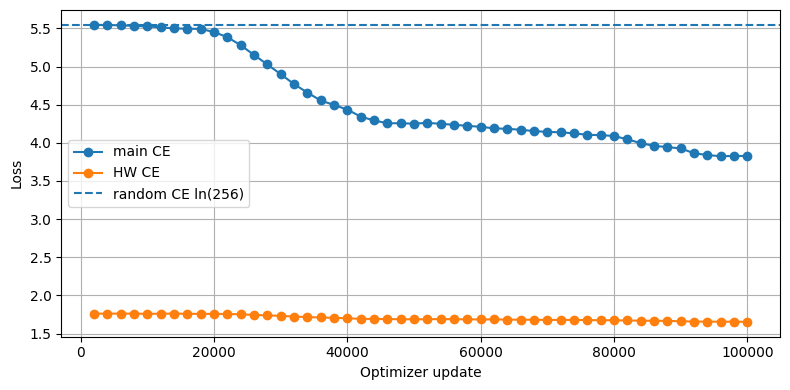

In [28]:
# ============================================================
model.train()
train_iter = infinite_loader(train_loader)

loss_window = []
main_window = []
hw_window = []
bit_window = []
acc_window = []
grad_window = []

pbar = tqdm(range(start_step + 1, TRAIN_STEPS + 1), desc="Training updates")

for step in pbar:
    lr = set_lr(step)
    optimizer.zero_grad(set_to_none=True)

    update_loss = 0.0
    update_main = 0.0
    update_hw = 0.0
    update_bit = 0.0
    update_acc = 0.0

    for micro_step in range(GRAD_ACCUM_STEPS):
        traces, labels, hw_labels, bit_labels = next(train_iter)
        traces = traces.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        hw_labels = hw_labels.to(DEVICE, non_blocking=True)
        bit_labels = bit_labels.to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
            outputs = model(traces, return_aux=True)
            main_loss = criterion_cls(outputs["logits"], labels)
            hw_loss = criterion_hw(outputs["hw_logits"], hw_labels)
            bit_loss = criterion_bits(outputs["bit_logits"], bit_labels)
            loss = main_loss + HW_AUX_WEIGHT * hw_loss + BIT_AUX_WEIGHT * bit_loss
            loss_for_backward = loss / GRAD_ACCUM_STEPS

        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite loss at step {step}: {loss.item()}")

        scaler.scale(loss_for_backward).backward()

        with torch.no_grad():
            acc = (outputs["logits"].argmax(dim=1) == labels).float().mean().item()

        update_loss += float(loss.item())
        update_main += float(main_loss.item())
        update_hw += float(hw_loss.item())
        update_bit += float(bit_loss.item())
        update_acc += float(acc)

    scaler.unscale_(optimizer)
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    scaler.step(optimizer)
    scaler.update()

    update_loss /= GRAD_ACCUM_STEPS
    update_main /= GRAD_ACCUM_STEPS
    update_hw /= GRAD_ACCUM_STEPS
    update_bit /= GRAD_ACCUM_STEPS
    update_acc /= GRAD_ACCUM_STEPS

    loss_window.append(update_loss)
    main_window.append(update_main)
    hw_window.append(update_hw)
    bit_window.append(update_bit)
    acc_window.append(update_acc)
    grad_window.append(float(grad_norm))

    if len(loss_window) > 200:
        loss_window.pop(0); main_window.pop(0); hw_window.pop(0); bit_window.pop(0); acc_window.pop(0); grad_window.pop(0)

    if step % 100 == 0:
        pbar.set_postfix({
            "main": np.mean(main_window),
            "hw": np.mean(hw_window),
            "acc": np.mean(acc_window),
            "lr": lr,
            "gnorm": np.mean(grad_window),
            "samples_M": step * EFFECTIVE_BATCH_SIZE / 1e6,
        })

    if step % SAVE_EVERY_STEPS == 0 or step == TRAIN_STEPS:
        row = {
            "step": int(step),
            "samples_seen": int(step * EFFECTIVE_BATCH_SIZE),
            "loss200": float(np.mean(loss_window)),
            "main_loss200": float(np.mean(main_window)),
            "hw_loss200": float(np.mean(hw_window)),
            "bit_loss200": float(np.mean(bit_window)),
            "acc200": float(np.mean(acc_window)),
            "lr": float(lr),
            "grad_norm200": float(np.mean(grad_window)),
            "train_batch_size": int(TRAIN_BATCH_SIZE),
            "grad_accum_steps": int(GRAD_ACCUM_STEPS),
            "effective_batch_size": int(EFFECTIVE_BATCH_SIZE),
        }
        history.append(row)
        pd.DataFrame(history).to_csv(RESULT_DIR / "training_history.csv", index=False)
        save_checkpoint(step, "last.pt")
        save_checkpoint(step, f"step_{step}.pt")
        print("Saved checkpoint:", row)

hist = pd.DataFrame(history)
display(hist.tail(20))

plt.figure(figsize=(8, 4))
plt.plot(hist["step"], hist["main_loss200"], marker="o", label="main CE")
plt.plot(hist["step"], hist["hw_loss200"], marker="o", label="HW CE")
plt.axhline(np.log(256), linestyle="--", label="random CE ln(256)")
plt.xlabel("Optimizer update")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "training_loss.png", dpi=180)
plt.show()

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


In [36]:
# ============================================================
# Rank-aware fine-tuning from the 100k checkpoint
#
# Purpose:
# The model already places the true key in top-2.
# This fine-tuning objective directly penalizes wrong key candidates
# during profiling training, instead of only optimizing per-trace CE.
# ============================================================

RANK_FT_START_CKPT = CKPT_DIR / "step_100000.pt"

RANK_FT_END_STEP = 110000
RANK_FT_SAVE_EVERY = 1000

RANK_FT_LR = 3e-5
RANK_FT_MIN_LR = 1e-5

# Keep these moderate. The main 256-class CE is still the main loss.
RANK_FT_KEY_CE_WEIGHT = 0.08
RANK_FT_KEY_MARGIN_WEIGHT = 0.05
RANK_FT_KEY_MARGIN = 0.02

RANK_FT_HW_AUX_WEIGHT = 0.05
RANK_FT_BIT_AUX_WEIGHT = 0.01

assert RANK_FT_START_CKPT.exists(), RANK_FT_START_CKPT

# Profiling key should be constant for ASCAD target byte.
PROFILE_TRUE_KEY = int(prof_key[0])
print("PROFILE_TRUE_KEY:", PROFILE_TRUE_KEY)
print("All profiling keys same:", np.all(prof_key == PROFILE_TRUE_KEY))

if not np.all(prof_key == PROFILE_TRUE_KEY):
    raise RuntimeError("Profiling key is not constant. Batch key-rank loss needs fixed profiling key.")


# ------------------------------------------------------------
# Dataset variant that also returns plaintext byte
# ------------------------------------------------------------
class ASCADTracePlainDataset(ASCADTraceDataset):
    def __init__(self, traces, labels, plaintexts, train=False):
        super().__init__(traces, labels, train=train)
        self.plaintexts = plaintexts.astype(np.uint8)

    def __getitem__(self, idx):
        trace, label, hw_label, bit_label = super().__getitem__(idx)
        plain = int(self.plaintexts[idx])

        return (
            trace,
            label,
            hw_label,
            bit_label,
            torch.tensor(plain, dtype=torch.long),
        )


rank_ft_ds = ASCADTracePlainDataset(
    X_prof,
    y_prof,
    prof_plain,
    train=True,
)

rank_ft_loader = DataLoader(
    rank_ft_ds,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Rank fine-tune batches:", len(rank_ft_loader))


# ------------------------------------------------------------
# Load 100k model weights
# Use a fresh optimizer for the new fine-tuning objective.
# ------------------------------------------------------------
ckpt = torch.load(
    RANK_FT_START_CKPT,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(ckpt["model"], strict=True)
model.train()

history = ckpt.get("history", [])
start_step = int(ckpt["step"])

print("Loaded model from:", RANK_FT_START_CKPT)
print("Starting rank-aware fine-tuning from step:", start_step)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=RANK_FT_LR,
    weight_decay=WEIGHT_DECAY,
)

try:
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


# ------------------------------------------------------------
# Torch constants for key-rank loss
# ------------------------------------------------------------
SBOX_TORCH = torch.tensor(
    SBOX.astype(np.int64),
    dtype=torch.long,
    device=DEVICE,
)

KEY_CANDIDATES_TORCH = torch.arange(
    256,
    dtype=torch.long,
    device=DEVICE,
)

PROFILE_TRUE_KEY_TENSOR = torch.tensor(
    [PROFILE_TRUE_KEY],
    dtype=torch.long,
    device=DEVICE,
)


def rank_ft_lr(step):
    """
    Cosine fine-tuning LR from RANK_FT_LR to RANK_FT_MIN_LR.
    """
    progress = (step - start_step) / max(1, RANK_FT_END_STEP - start_step)
    progress = min(1.0, max(0.0, progress))

    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))

    return RANK_FT_MIN_LR + (RANK_FT_LR - RANK_FT_MIN_LR) * cosine


def set_rank_ft_lr(step):
    lr = rank_ft_lr(step)

    for group in optimizer.param_groups:
        group["lr"] = lr

    return lr


def batch_key_rank_losses(logits, plaintext_bytes):
    """
    Converts per-trace class log-probabilities into batch-level key scores.

    For each trace i and key guess k:
        label_guess = SBOX[plaintext_i xor k]

    Then:
        score[k] = mean_i log p(label_guess_i,k | trace_i)

    The correct profiling key should have the largest score.
    """
    log_probs = F.log_softmax(logits.float(), dim=1)

    plaintext_bytes = plaintext_bytes.to(DEVICE, non_blocking=True).long()

    hyp_inputs = torch.bitwise_xor(
        plaintext_bytes[:, None],
        KEY_CANDIDATES_TORCH[None, :],
    )

    hyp_labels = SBOX_TORCH[hyp_inputs]              # [B, 256]

    selected_log_probs = log_probs.gather(1, hyp_labels)  # [B, 256]

    key_scores = selected_log_probs.mean(dim=0)      # [256]

    key_ce_loss = F.cross_entropy(
        key_scores.unsqueeze(0),
        PROFILE_TRUE_KEY_TENSOR,
    )

    true_score = key_scores[PROFILE_TRUE_KEY]

    wrong_mask = torch.ones(256, dtype=torch.bool, device=DEVICE)
    wrong_mask[PROFILE_TRUE_KEY] = False

    wrong_scores = key_scores[wrong_mask]

    top_wrong = torch.topk(
        wrong_scores,
        k=min(16, wrong_scores.numel()),
    ).values

    # Push the strongest wrong keys below the true key by a small margin.
    key_margin_loss = F.softplus(
        top_wrong - true_score + RANK_FT_KEY_MARGIN,
    ).mean()

    return key_ce_loss, key_margin_loss


def save_rank_ft_checkpoint(step, name=None):
    if name is None:
        name = f"step_{step}.pt"

    ckpt_out = {
        "step": int(step),
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scaler": scaler.state_dict(),
        "history": history,
        "rank_finetune": True,
        "rank_finetune_config": {
            "start_checkpoint": str(RANK_FT_START_CKPT),
            "rank_ft_start_step": int(start_step),
            "rank_ft_end_step": int(RANK_FT_END_STEP),
            "rank_ft_lr": float(RANK_FT_LR),
            "rank_ft_min_lr": float(RANK_FT_MIN_LR),
            "key_ce_weight": float(RANK_FT_KEY_CE_WEIGHT),
            "key_margin_weight": float(RANK_FT_KEY_MARGIN_WEIGHT),
            "key_margin": float(RANK_FT_KEY_MARGIN),
            "hw_aux_weight": float(RANK_FT_HW_AUX_WEIGHT),
            "bit_aux_weight": float(RANK_FT_BIT_AUX_WEIGHT),
            "profile_true_key": int(PROFILE_TRUE_KEY),
        },
    }

    torch.save(ckpt_out, CKPT_DIR / name)


# ------------------------------------------------------------
# Rank-aware fine-tuning loop
# ------------------------------------------------------------
rank_ft_iter = infinite_loader(rank_ft_loader)

loss_window = []
main_window = []
key_ce_window = []
key_margin_window = []
acc_window = []
grad_window = []

pbar = tqdm(
    range(start_step + 1, RANK_FT_END_STEP + 1),
    desc="Rank-aware fine-tune",
)

for step in pbar:
    lr = set_rank_ft_lr(step)

    optimizer.zero_grad(set_to_none=True)

    update_loss = 0.0
    update_main = 0.0
    update_key_ce = 0.0
    update_key_margin = 0.0
    update_acc = 0.0

    for micro_step in range(GRAD_ACCUM_STEPS):
        traces, labels, hw_labels, bit_labels, plaintext_bytes = next(rank_ft_iter)

        traces = traces.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        hw_labels = hw_labels.to(DEVICE, non_blocking=True)
        bit_labels = bit_labels.to(DEVICE, non_blocking=True)
        plaintext_bytes = plaintext_bytes.to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
            outputs = model(traces, return_aux=True)

            main_loss = criterion_cls(outputs["logits"], labels)
            hw_loss = criterion_hw(outputs["hw_logits"], hw_labels)
            bit_loss = criterion_bits(outputs["bit_logits"], bit_labels)

            key_ce_loss, key_margin_loss = batch_key_rank_losses(
                outputs["logits"],
                plaintext_bytes,
            )

            loss = (
                main_loss
                + RANK_FT_HW_AUX_WEIGHT * hw_loss
                + RANK_FT_BIT_AUX_WEIGHT * bit_loss
                + RANK_FT_KEY_CE_WEIGHT * key_ce_loss
                + RANK_FT_KEY_MARGIN_WEIGHT * key_margin_loss
            )

            loss_for_backward = loss / GRAD_ACCUM_STEPS

        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite fine-tune loss at step {step}: {loss.item()}")

        scaler.scale(loss_for_backward).backward()

        with torch.no_grad():
            acc = (outputs["logits"].argmax(dim=1) == labels).float().mean().item()

        update_loss += float(loss.item())
        update_main += float(main_loss.item())
        update_key_ce += float(key_ce_loss.item())
        update_key_margin += float(key_margin_loss.item())
        update_acc += float(acc)

    scaler.unscale_(optimizer)

    grad_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        GRAD_CLIP,
    )

    scaler.step(optimizer)
    scaler.update()

    update_loss /= GRAD_ACCUM_STEPS
    update_main /= GRAD_ACCUM_STEPS
    update_key_ce /= GRAD_ACCUM_STEPS
    update_key_margin /= GRAD_ACCUM_STEPS
    update_acc /= GRAD_ACCUM_STEPS

    loss_window.append(update_loss)
    main_window.append(update_main)
    key_ce_window.append(update_key_ce)
    key_margin_window.append(update_key_margin)
    acc_window.append(update_acc)
    grad_window.append(float(grad_norm))

    if len(loss_window) > 200:
        loss_window.pop(0)
        main_window.pop(0)
        key_ce_window.pop(0)
        key_margin_window.pop(0)
        acc_window.pop(0)
        grad_window.pop(0)

    if step % 100 == 0:
        pbar.set_postfix({
            "loss200": np.mean(loss_window),
            "main200": np.mean(main_window),
            "key_ce200": np.mean(key_ce_window),
            "key_m200": np.mean(key_margin_window),
            "acc200": np.mean(acc_window),
            "lr": lr,
            "gnorm200": np.mean(grad_window),
        })

    if step % RANK_FT_SAVE_EVERY == 0 or step == RANK_FT_END_STEP:
        row = {
            "step": int(step),
            "rank_finetune": True,
            "loss200": float(np.mean(loss_window)),
            "main200": float(np.mean(main_window)),
            "key_ce200": float(np.mean(key_ce_window)),
            "key_margin200": float(np.mean(key_margin_window)),
            "acc200": float(np.mean(acc_window)),
            "lr": float(lr),
            "grad_norm200": float(np.mean(grad_window)),
        }

        history.append(row)

        pd.DataFrame(history).to_csv(
            RESULT_DIR / "training_history_rank_finetune.csv",
            index=False,
        )

        save_rank_ft_checkpoint(step)
        save_rank_ft_checkpoint(step, "last_rankft.pt")

        print("Saved rank-aware fine-tune checkpoint:", row)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

PROFILE_TRUE_KEY: 224
All profiling keys same: True
Rank fine-tune batches: 390
Loaded model from: /kaggle/working/hdt_desync100_standard_d128_w50_bs128x2_norm-global_aug0_ckpt/step_100000.pt
Starting rank-aware fine-tuning from step: 100000


Rank-aware fine-tune:   0%|          | 0/10000 [00:00<?, ?it/s]

Saved rank-aware fine-tune checkpoint: {'step': 101000, 'rank_finetune': True, 'loss200': 4.092200565934181, 'main200': 3.8617130488157274, 'key_ce200': 1.7395635016262532, 'key_margin200': 0.02947820272296667, 'acc200': 0.2069921875, 'lr': 2.9510565162951534e-05, 'grad_norm200': 4.519942256212235}
Saved rank-aware fine-tune checkpoint: {'step': 102000, 'rank_finetune': True, 'loss200': 4.08351797580719, 'main200': 3.8569294387102127, 'key_ce200': 1.6919515922665596, 'key_margin200': 0.0280705995997414, 'acc200': 0.20931640625, 'lr': 2.8090169943749472e-05, 'grad_norm200': 4.605966023206711}
Saved rank-aware fine-tune checkpoint: {'step': 103000, 'rank_finetune': True, 'loss200': 4.0688237655162816, 'main200': 3.8460076278448105, 'key_ce200': 1.642624653726816, 'key_margin200': 0.026691614573355765, 'acc200': 0.2101171875, 'lr': 2.5877852522924728e-05, 'grad_norm200': 4.657836550474167}
Saved rank-aware fine-tune checkpoint: {'step': 104000, 'rank_finetune': True, 'loss200': 4.07007533

Rank-aware fine-tuned checkpoints:
 - step_100000.pt
 - step_101000.pt
 - step_102000.pt
 - step_103000.pt
 - step_104000.pt
 - step_105000.pt
 - step_106000.pt
 - step_107000.pt
 - step_108000.pt
 - step_109000.pt
 - step_110000.pt
 - last_rankft.pt

Evaluating rank-aware checkpoint: step_100000.pt


Predict step_100000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/100 [00:00<?, ?it/s]

{'checkpoint': 'step_100000.pt', 'step': 100000, 'attack_acc': 0.0031, 'single_final_rank': 2, 'single_min_rank': 0, 'single_traces_to_rank0': 6970, 'ge_final': 2.0, 'ge_min': 2.0, 'traces_to_ge_below_1': None}

Evaluating rank-aware checkpoint: step_101000.pt


Predict step_101000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

...

{'checkpoint': 'step_110000.pt', 'step': 110000, 'attack_acc': 0.0032, 'single_final_rank': 2, 'single_min_rank': 0, 'single_traces_to_rank0': 9236, 'ge_final': 2.0, 'ge_min': 2.0, 'traces_to_ge_below_1': None}

Evaluating rank-aware checkpoint: last_rankft.pt


Predict last_rankft.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/100 [00:00<?, ?it/s]

{'checkpoint': 'last_rankft.pt', 'step': 110000, 'attack_acc': 0.0032, 'single_final_rank': 2, 'single_min_rank': 0, 'single_traces_to_rank0': 9236, 'ge_final': 2.0, 'ge_min': 2.0, 'traces_to_ge_below_1': None}


,checkpoint,step,attack_acc,single_final_rank,single_min_rank,single_traces_to_rank0,ge_final,ge_min,traces_to_ge_below_1
0,step_100000.pt,100000,0.0031,2,0,6970,2.0,2.0,None
1,step_101000.pt,101000,0.0033,2,0,8078,2.0,2.0,None
2,step_102000.pt,102000,0.0033,2,0,9236,2.0,2.0,None
3,step_103000.pt,103000,0.0033,2,0,8189,2.0,2.0,None
4,step_104000.pt,104000,0.0030,2,0,9254,2.0,2.0,None
5,step_105000.pt,105000,0.0035,2,0,9395,2.0,2.0,None
6,step_106000.pt,106000,0.0032,2,0,9239,2.0,2.0,None
7,step_107000.pt,107000,0.0034,2,0,9395,2.0,2.0,None
8,step_108000.pt,108000,0.0033,2,0,9237,2.0,2.0,None
9,step_109000.pt,109000,0.0034,2,0,9395,2.0,2.0,None


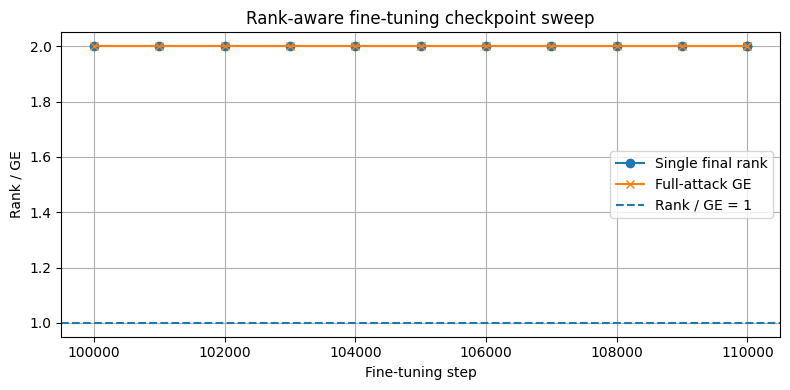

In [37]:
# ============================================================
# Evaluate rank-aware fine-tuned Transformer checkpoints
# ============================================================

MIN_EVAL_STEP = 100000
N_RANK_REPEATS = 100
ATTACK_TRACES_FOR_GE = len(attack_plain)

rankft_ckpt_paths = sorted(
    [
        p for p in CKPT_DIR.glob("step_*.pt")
        if checkpoint_sort_key(p) >= MIN_EVAL_STEP
    ],
    key=checkpoint_sort_key,
)

# Include last_rankft.pt if it exists.
last_rankft_path = CKPT_DIR / "last_rankft.pt"
if last_rankft_path.exists():
    rankft_ckpt_paths.append(last_rankft_path)

print("Rank-aware fine-tuned checkpoints:")
for p in rankft_ckpt_paths:
    print(" -", p.name)

if len(rankft_ckpt_paths) == 0:
    raise FileNotFoundError(f"No rank-aware checkpoints found at or after step {MIN_EVAL_STEP}")

rankft_rows = []
rankft_best = None

for p in rankft_ckpt_paths:
    print("\nEvaluating rank-aware checkpoint:", p.name)

    row, single_curve, ge_mean, ge_std, logits = evaluate_checkpoint(
        p,
        n_repeats=N_RANK_REPEATS,
        n_traces=ATTACK_TRACES_FOR_GE,
    )

    rankft_rows.append(row)
    print(row)

    if rankft_best is None:
        rankft_best = {
            "row": row,
            "path": p,
            "single_curve": single_curve,
            "ge_mean": ge_mean,
            "ge_std": ge_std,
            "logits": logits,
        }
    else:
        old_score = (
            rankft_best["row"]["single_final_rank"],
            rankft_best["row"]["ge_final"],
            rankft_best["row"]["ge_min"],
        )
        new_score = (
            row["single_final_rank"],
            row["ge_final"],
            row["ge_min"],
        )

        if new_score < old_score:
            rankft_best = {
                "row": row,
                "path": p,
                "single_curve": single_curve,
                "ge_mean": ge_mean,
                "ge_std": ge_std,
                "logits": logits,
            }

rankft_df = pd.DataFrame(rankft_rows).sort_values("step")
display(rankft_df)

rankft_df.to_csv(
    RESULT_DIR / "rankaware_finetune_checkpoint_sweep.csv",
    index=False,
)

plt.figure(figsize=(8, 4))
plt.plot(rankft_df["step"], rankft_df["single_final_rank"], marker="o", label="Single final rank")
plt.plot(rankft_df["step"], rankft_df["ge_final"], marker="x", label="Full-attack GE")
plt.axhline(1, linestyle="--", label="Rank / GE = 1")
plt.xlabel("Fine-tuning step")
plt.ylabel("Rank / GE")
plt.title("Rank-aware fine-tuning checkpoint sweep")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "rankaware_finetune_checkpoint_sweep.png", dpi=180)
plt.show()

In [38]:
# ============================================================
# Diagnostic: identify hard wrong key candidates
# Uses profiling data for hard-negative mining.
# Attack top keys are printed only for diagnosis.
# ============================================================

HARDNEG_START_CKPT = CKPT_DIR / "step_100000.pt"

assert HARDNEG_START_CKPT.exists(), HARDNEG_START_CKPT

load_checkpoint_for_eval(HARDNEG_START_CKPT)

PROFILE_TRUE_KEY = int(prof_key[0])
print("PROFILE_TRUE_KEY:", PROFILE_TRUE_KEY)
print("All profiling keys same:", np.all(prof_key == PROFILE_TRUE_KEY))


def key_scores_from_log_probs(log_probs, plaintexts):
    key_scores = np.zeros(256, dtype=np.float64)
    key_candidates = np.arange(256, dtype=np.uint8)

    for i in range(len(log_probs)):
        pt = np.uint8(plaintexts[i])
        hyp_labels = SBOX[np.bitwise_xor(pt, key_candidates)]
        key_scores += log_probs[i, hyp_labels]

    return key_scores


def print_top_keys(key_scores, true_key, title, topn=12):
    order = np.argsort(-key_scores)
    true_rank = int(np.where(order == true_key)[0][0])

    print("\n" + "=" * 80)
    print(title)
    print("true key:", true_key)
    print("true rank:", true_rank)
    print("true score:", key_scores[true_key])
    print("=" * 80)

    for r, k in enumerate(order[:topn]):
        print(
            f"rank={r:2d} key={int(k):3d} "
            f"score={key_scores[k]:.6f} "
            f"gap_vs_true={key_scores[k] - key_scores[true_key]:.6f}"
        )

    return order, true_rank


# Attack diagnostic.
attack_logits, _ = predict_logits(
    model,
    attack_loader,
    desc="Attack hard-negative diagnostic",
)

attack_log_probs = stable_log_softmax_np(attack_logits)

attack_key_scores = key_scores_from_log_probs(
    attack_log_probs,
    attack_plain,
)

attack_order, attack_true_rank = print_top_keys(
    attack_key_scores,
    ATTACK_TRUE_KEY,
    "ATTACK top keys, diagnostic only",
    topn=12,
)


# Profiling hard-negative mining.
profile_eval_ds = ASCADTraceDataset(
    X_prof,
    y_prof,
    train=False,
)

profile_eval_loader = DataLoader(
    profile_eval_ds,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

profile_logits, _ = predict_logits(
    model,
    profile_eval_loader,
    desc="Profiling hard-negative diagnostic",
)

profile_log_probs = stable_log_softmax_np(profile_logits)

profile_key_scores = key_scores_from_log_probs(
    profile_log_probs,
    prof_plain,
)

profile_order, profile_true_rank = print_top_keys(
    profile_key_scores,
    PROFILE_TRUE_KEY,
    "PROFILING top keys used for hard-negative mining",
    topn=20,
)

hard_neg_keys = [
    int(k)
    for k in profile_order
    if int(k) != PROFILE_TRUE_KEY
][:16]

print("\nHard negative keys from profiling:")
print(hard_neg_keys)

print("\nAttack top wrong keys, diagnostic only:")
print([int(k) for k in attack_order if int(k) != ATTACK_TRUE_KEY][:8])

PROFILE_TRUE_KEY: 224
All profiling keys same: True


Attack hard-negative diagnostic:   0%|          | 0/79 [00:00<?, ?it/s]


ATTACK top keys, diagnostic only
true key: 224
true rank: 2
true score: -80474.11274536474
rank= 0 key=  7 score=-80326.300590 gap_vs_true=147.812156
rank= 1 key=241 score=-80345.018951 gap_vs_true=129.093794
rank= 2 key=224 score=-80474.112745 gap_vs_true=0.000000
rank= 3 key= 90 score=-80556.451355 gap_vs_true=-82.338610
rank= 4 key= 59 score=-80579.592551 gap_vs_true=-105.479805
rank= 5 key=138 score=-80580.561812 gap_vs_true=-106.449067
rank= 6 key= 22 score=-80581.872245 gap_vs_true=-107.759500
rank= 7 key= 50 score=-80598.356790 gap_vs_true=-124.244044
rank= 8 key= 81 score=-80600.204907 gap_vs_true=-126.092161
rank= 9 key=104 score=-80625.387337 gap_vs_true=-151.274592
rank=10 key=112 score=-80636.764524 gap_vs_true=-162.651778
rank=11 key=190 score=-80636.814647 gap_vs_true=-162.701901


Profiling hard-negative diagnostic:   0%|          | 0/391 [00:00<?, ?it/s]


PROFILING top keys used for hard-negative mining
true key: 224
true rank: 0
true score: -192850.47635795202
rank= 0 key=224 score=-192850.476358 gap_vs_true=0.000000
rank= 1 key=213 score=-413312.858235 gap_vs_true=-220462.381877
rank= 2 key=178 score=-414064.659699 gap_vs_true=-221214.183341
rank= 3 key=152 score=-414484.788579 gap_vs_true=-221634.312221
rank= 4 key=238 score=-414933.907239 gap_vs_true=-222083.430881
rank= 5 key= 60 score=-415210.673058 gap_vs_true=-222360.196700
rank= 6 key= 58 score=-415226.708480 gap_vs_true=-222376.232122
rank= 7 key= 78 score=-415353.294541 gap_vs_true=-222502.818183
rank= 8 key=123 score=-415379.405587 gap_vs_true=-222528.929229
rank= 9 key= 16 score=-415642.161595 gap_vs_true=-222791.685237
rank=10 key=  0 score=-415684.838516 gap_vs_true=-222834.362158
rank=11 key=  2 score=-415749.413183 gap_vs_true=-222898.936825
rank=12 key=164 score=-415774.680106 gap_vs_true=-222924.203748
rank=13 key=  6 score=-415908.925465 gap_vs_true=-223058.449107
r

Checkpoints:
 - step_90000.pt
 - step_92000.pt
 - step_94000.pt
 - step_96000.pt
 - step_98000.pt
 - step_100000.pt

Evaluating checkpoint: step_90000.pt


Predict step_90000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/30 [00:00<?, ?it/s]

{'checkpoint': 'step_90000.pt', 'step': 90000, 'attack_acc': 0.0031, 'single_final_rank': 2, 'single_min_rank': 0, 'single_traces_to_rank0': 9144, 'ge_final': 28.733333333333334, 'ge_min': 27.7, 'traces_to_ge_below_1': None}

Evaluating checkpoint: step_92000.pt


Predict step_92000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

...

{'checkpoint': 'step_98000.pt', 'step': 98000, 'attack_acc': 0.0038, 'single_final_rank': 2, 'single_min_rank': 0, 'single_traces_to_rank0': 6970, 'ge_final': 27.633333333333333, 'ge_min': 26.766666666666666, 'traces_to_ge_below_1': None}

Evaluating checkpoint: step_100000.pt


Predict step_100000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/30 [00:00<?, ?it/s]

{'checkpoint': 'step_100000.pt', 'step': 100000, 'attack_acc': 0.0031, 'single_final_rank': 2, 'single_min_rank': 0, 'single_traces_to_rank0': 6970, 'ge_final': 26.0, 'ge_min': 25.033333333333335, 'traces_to_ge_below_1': None}


,checkpoint,step,attack_acc,single_final_rank,single_min_rank,single_traces_to_rank0,ge_final,ge_min,traces_to_ge_below_1
0,step_90000.pt,90000,0.0031,2,0,9144,28.733333,27.700000,None
1,step_92000.pt,92000,0.0040,2,0,9400,25.566667,24.900000,None
2,step_94000.pt,94000,0.0032,2,0,6975,25.566667,24.966667,None
3,step_96000.pt,96000,0.0032,2,0,9391,30.500000,29.900000,None
4,step_98000.pt,98000,0.0038,2,0,6970,27.633333,26.766667,None
5,step_100000.pt,100000,0.0031,2,0,6970,26.000000,25.033333,None


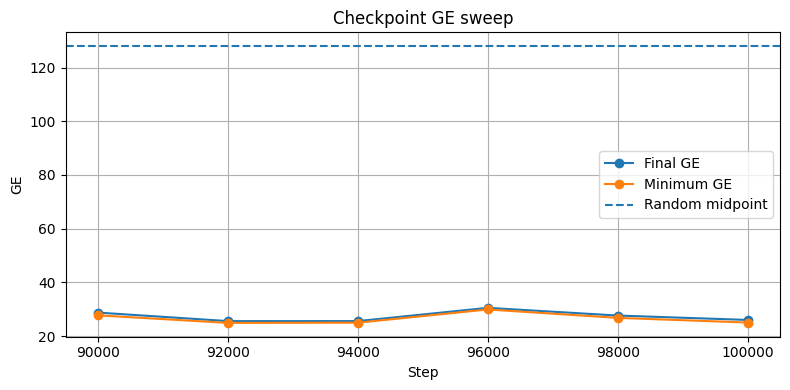

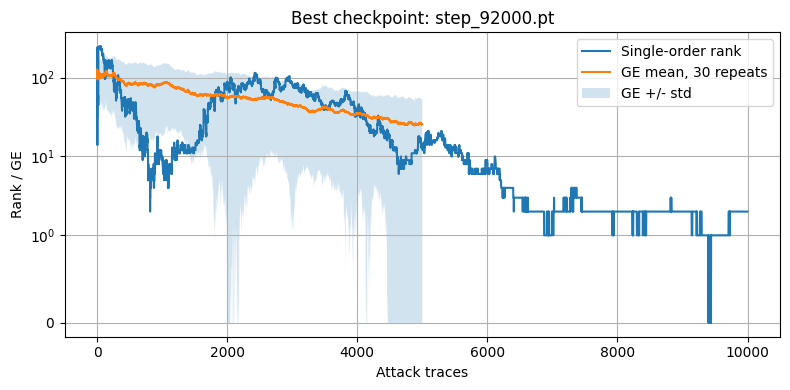

{
  "model_tag": "hdt_desync100_standard_d128_w50_bs128x2_norm-global_aug0",
  "dataset_tag": "desync100",
  "ascad_path": "/kaggle/input/datasets/govindgopakumar/ascad-dataset/ASCAD_data/ASCAD_databases/ASCAD_desync100.h5",
  "true_key": 224,
  "best_checkpoint": {
    "checkpoint": "step_92000.pt",
    "step": 92000,
    "attack_acc": 0.004,
    "single_final_rank": 2,
    "single_min_rank": 0,
    "single_traces_to_rank0": 9400,
    "ge_final": 25.566666666666666,
    "ge_min": 24.9,
    "traces_to_ge_below_1": null
  },
  "num_params": 2230073,
  "norm_mode": "global",
  "aug_shift": 0,
  "effective_batch_size": 256,
  "hw_aux_weight": 0.2,
  "bit_aux_weight": 0.05
}


In [29]:
# ============================================================
@torch.no_grad()
def predict_logits(model, loader, desc="Predict"):
    model.eval()
    all_logits = []
    all_labels = []
    for batch in tqdm(loader, desc=desc, leave=False):
        traces, labels = batch[0], batch[1]
        traces = traces.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
            logits = model(traces, return_aux=False)
        all_logits.append(logits.float().cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_logits, axis=0), np.concatenate(all_labels, axis=0)


def checkpoint_sort_key(path):
    m = re.search(r"step_(\d+)", path.name)
    if m:
        return int(m.group(1))
    if path.name == "last.pt":
        return 10**12
    return -1


def load_checkpoint_for_eval(path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model"], strict=True)
    return int(ckpt.get("step", checkpoint_sort_key(path)))


def evaluate_checkpoint(path, n_repeats=N_RANK_REPEATS, n_traces=ATTACK_TRACES_FOR_GE):
    step = load_checkpoint_for_eval(path)
    logits, labels = predict_logits(model, attack_loader, desc=f"Predict {path.name}")
    log_probs = stable_log_softmax_np(logits)

    pred = logits.argmax(axis=1)
    attack_acc = float(np.mean(pred == y_attack))

    single_curve = rank_curve_from_log_probs(log_probs, attack_plain, ATTACK_TRUE_KEY)
    ge_mean, ge_std, ge_curves = guessing_entropy_from_log_probs(
        log_probs,
        attack_plain,
        ATTACK_TRUE_KEY,
        n_traces=min(n_traces, len(log_probs)),
        n_repeats=n_repeats,
        seed=SEED + 777,
    )
    metrics = metrics_from_ge(single_curve, ge_mean)
    row = {
        "checkpoint": path.name,
        "step": int(step),
        "attack_acc": attack_acc,
        **metrics,
    }
    return row, single_curve, ge_mean, ge_std, logits

MIN_EVAL_STEP = 90000

ckpt_paths = sorted(
    [
        p for p in CKPT_DIR.glob("step_*.pt")
        if checkpoint_sort_key(p) >= MIN_EVAL_STEP
    ],
    key=checkpoint_sort_key,
)
if len(ckpt_paths) == 0 and (CKPT_DIR / "last.pt").exists():
    last_step = load_checkpoint_for_eval(CKPT_DIR / "last.pt")

    if last_step >= MIN_EVAL_STEP:
        ckpt_paths = [CKPT_DIR / "last.pt"]
    else:
        raise FileNotFoundError(
            f"No checkpoints found at or after step {MIN_EVAL_STEP} in {CKPT_DIR}"
        )

print("Checkpoints:")
for p in ckpt_paths:
    print(" -", p.name)

if len(ckpt_paths) == 0:
    raise FileNotFoundError(f"No checkpoints found in {CKPT_DIR}")

sweep_rows = []
best = None

for p in ckpt_paths:
    print("\nEvaluating checkpoint:", p.name)
    row, single_curve, ge_mean, ge_std, logits = evaluate_checkpoint(p)
    sweep_rows.append(row)
    print(row)
    if best is None or row["ge_final"] < best["row"]["ge_final"]:
        best = {"row": row, "path": p, "single_curve": single_curve, "ge_mean": ge_mean, "ge_std": ge_std, "logits": logits}

sweep_df = pd.DataFrame(sweep_rows).sort_values("step")
display(sweep_df)
sweep_df.to_csv(RESULT_DIR / "checkpoint_rank_ge_sweep.csv", index=False)

plt.figure(figsize=(8, 4))
plt.plot(sweep_df["step"], sweep_df["ge_final"], marker="o", label="Final GE")
plt.plot(sweep_df["step"], sweep_df["ge_min"], marker="o", label="Minimum GE")
plt.axhline(128, linestyle="--", label="Random midpoint")
plt.xlabel("Step")
plt.ylabel("GE")
plt.title("Checkpoint GE sweep")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "checkpoint_ge_sweep.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(best["single_curve"], label="Single-order rank")
plt.plot(best["ge_mean"], label=f"GE mean, {N_RANK_REPEATS} repeats")
plt.fill_between(
    np.arange(len(best["ge_mean"])),
    np.maximum(best["ge_mean"] - best["ge_std"], 0),
    best["ge_mean"] + best["ge_std"],
    alpha=0.2,
    label="GE +/- std",
)
plt.xlabel("Attack traces")
plt.ylabel("Rank / GE")
plt.yscale("symlog", linthresh=1)
plt.title(f"Best checkpoint: {best['path'].name}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "best_rank_ge_curve.png", dpi=180)
plt.show()

summary = {
    "model_tag": MODEL_TAG,
    "dataset_tag": DATASET_TAG,
    "ascad_path": ASCAD_PATH,
    "true_key": int(ATTACK_TRUE_KEY),
    "best_checkpoint": best["row"],
    "num_params": int(num_params),
    "norm_mode": NORM_MODE,
    "aug_shift": int(AUG_SHIFT),
    "effective_batch_size": int(EFFECTIVE_BATCH_SIZE),
    "hw_aux_weight": float(HW_AUX_WEIGHT),
    "bit_aux_weight": float(BIT_AUX_WEIGHT),
}
with open(RESULT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))



Full attack evaluation: step_90000.pt


Predict step_90000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/100 [00:00<?, ?it/s]

{'checkpoint': 'step_90000.pt', 'step': 90000, 'attack_acc': 0.0031, 'single_final_rank': 2, 'single_min_rank': 0, 'single_traces_to_rank0': 9144, 'ge_final': 2.0, 'ge_min': 2.0, 'traces_to_ge_below_1': None}

Full attack evaluation: step_92000.pt


Predict step_92000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

...

{'checkpoint': 'step_98000.pt', 'step': 98000, 'attack_acc': 0.0038, 'single_final_rank': 2, 'single_min_rank': 0, 'single_traces_to_rank0': 6970, 'ge_final': 2.0, 'ge_min': 2.0, 'traces_to_ge_below_1': None}

Full attack evaluation: step_100000.pt


Predict step_100000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/100 [00:00<?, ?it/s]

{'checkpoint': 'step_100000.pt', 'step': 100000, 'attack_acc': 0.0031, 'single_final_rank': 2, 'single_min_rank': 0, 'single_traces_to_rank0': 6970, 'ge_final': 2.0, 'ge_min': 2.0, 'traces_to_ge_below_1': None}


,checkpoint,step,attack_acc,single_final_rank,single_min_rank,single_traces_to_rank0,ge_final,ge_min,traces_to_ge_below_1
0,step_90000.pt,90000,0.0031,2,0,9144,2.0,2.0,None
1,step_92000.pt,92000,0.0040,2,0,9400,2.0,2.0,None
2,step_94000.pt,94000,0.0032,2,0,6975,2.0,2.0,None
3,step_96000.pt,96000,0.0032,2,0,9391,2.0,2.0,None
4,step_98000.pt,98000,0.0038,2,0,6970,2.0,2.0,None
5,step_100000.pt,100000,0.0031,2,0,6970,2.0,2.0,None


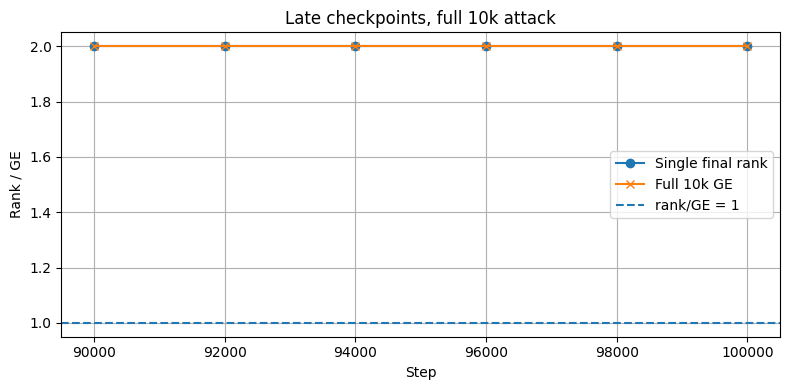

In [32]:
# ============================================================
# Full 10k attack evaluation for late checkpoints
# ============================================================

FULL_ATTACK_TRACES = len(attack_plain)
FULL_REPEATS = 100

MIN_EVAL_STEP = 90000

late_ckpt_paths = sorted(
    [
        p for p in CKPT_DIR.glob("step_*.pt")
        if checkpoint_sort_key(p) >= MIN_EVAL_STEP
    ],
    key=checkpoint_sort_key,
)

full_rows = []

for p in late_ckpt_paths:
    print("\nFull attack evaluation:", p.name)

    row, single_curve, ge_mean, ge_std, logits = evaluate_checkpoint(
        p,
        n_repeats=FULL_REPEATS,
        n_traces=FULL_ATTACK_TRACES,
    )

    full_rows.append(row)
    print(row)

full_df = pd.DataFrame(full_rows).sort_values("step")
display(full_df)

full_df.to_csv(
    RESULT_DIR / "late_full_10k_attack_eval.csv",
    index=False,
)

plt.figure(figsize=(8, 4))
plt.plot(full_df["step"], full_df["single_final_rank"], marker="o", label="Single final rank")
plt.plot(full_df["step"], full_df["ge_final"], marker="x", label="Full 10k GE")
plt.axhline(1, linestyle="--", label="rank/GE = 1")
plt.xlabel("Step")
plt.ylabel("Rank / GE")
plt.title("Late checkpoints, full 10k attack")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "late_full_10k_attack_eval.png", dpi=180)
plt.show()

In [33]:
# ============================================================
# SWA / weight-averaged checkpoint over late HDT checkpoints
# Produces one single averaged model checkpoint.
# ============================================================

SWA_STEPS = [90000, 92000, 94000, 96000, 98000, 100000]
SWA_NAME = "swa_90000_100000.pt"

swa_paths = [
    CKPT_DIR / f"step_{s}.pt"
    for s in SWA_STEPS
    if (CKPT_DIR / f"step_{s}.pt").exists()
]

print("SWA checkpoints:")
for p in swa_paths:
    print(" -", p.name)

if len(swa_paths) == 0:
    raise FileNotFoundError("No SWA checkpoints found.")

avg_state = None
num_states = 0
last_ckpt = None

for p in swa_paths:
    ckpt = torch.load(
        p,
        map_location="cpu",
        weights_only=False,
    )

    state = ckpt["model"]
    last_ckpt = ckpt

    if avg_state is None:
        avg_state = {}

        for k, v in state.items():
            if torch.is_floating_point(v):
                avg_state[k] = v.detach().float().clone()
            else:
                avg_state[k] = v.detach().clone()
    else:
        for k, v in state.items():
            if torch.is_floating_point(v):
                avg_state[k] += v.detach().float()

    num_states += 1

for k, v in avg_state.items():
    if torch.is_floating_point(v):
        avg_state[k] = v / float(num_states)

swa_ckpt = {
    "step": max(SWA_STEPS),
    "model": avg_state,
    "swa_steps": SWA_STEPS,
    "source_checkpoints": [p.name for p in swa_paths],
    "config": last_ckpt.get("config", {}),
}

swa_path = CKPT_DIR / SWA_NAME

torch.save(swa_ckpt, swa_path)

print("Saved SWA checkpoint:", swa_path)

SWA checkpoints:
 - step_90000.pt
 - step_92000.pt
 - step_94000.pt
 - step_96000.pt
 - step_98000.pt
 - step_100000.pt
Saved SWA checkpoint: /kaggle/working/hdt_desync100_standard_d128_w50_bs128x2_norm-global_aug0_ckpt/swa_90000_100000.pt


Predict swa_90000_100000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/100 [00:00<?, ?it/s]

SWA metrics:
{'checkpoint': 'swa_90000_100000.pt', 'step': 100000, 'attack_acc': 0.0036, 'single_final_rank': 2, 'single_min_rank': 0, 'single_traces_to_rank0': 8175, 'ge_final': 2.0, 'ge_min': 2.0, 'traces_to_ge_below_1': None}


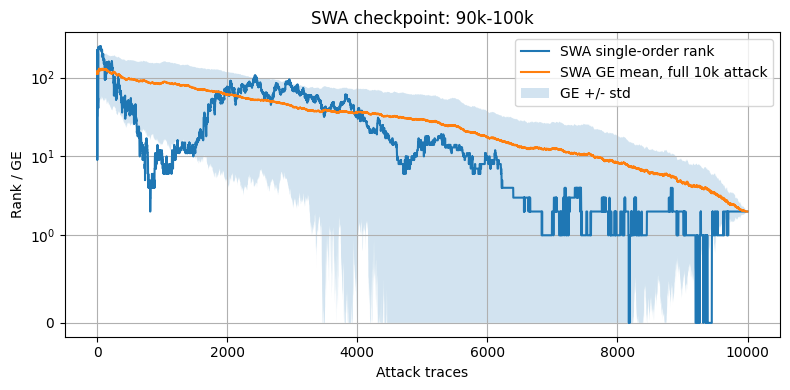

In [34]:
# ============================================================
# Evaluate SWA checkpoint
# ============================================================

swa_row, swa_single_curve, swa_ge_mean, swa_ge_std, swa_logits = evaluate_checkpoint(
    swa_path,
    n_repeats=100,
    n_traces=len(attack_plain),
)

print("SWA metrics:")
print(swa_row)

plt.figure(figsize=(8, 4))
plt.plot(swa_single_curve, label="SWA single-order rank")
plt.plot(swa_ge_mean, label="SWA GE mean, full 10k attack")
plt.fill_between(
    np.arange(len(swa_ge_mean)),
    np.maximum(swa_ge_mean - swa_ge_std, 0),
    swa_ge_mean + swa_ge_std,
    alpha=0.2,
    label="GE +/- std",
)
plt.xlabel("Attack traces")
plt.ylabel("Rank / GE")
plt.yscale("symlog", linthresh=1)
plt.title("SWA checkpoint: 90k-100k")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "swa_90000_100000_rank_ge.png", dpi=180)
plt.show()

Ensemble checkpoints:
 - step_90000.pt
 - step_92000.pt
 - step_94000.pt
 - step_96000.pt
 - step_98000.pt
 - step_100000.pt


Predict step_90000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

Predict step_92000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

Predict step_94000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

Predict step_96000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

Predict step_98000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

Predict step_100000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/100 [00:00<?, ?it/s]

Ensemble metrics:
{'single_final_rank': 2, 'single_min_rank': 0, 'single_traces_to_rank0': 9204, 'ge_final': 2.0, 'ge_min': 2.0, 'traces_to_ge_below_1': None}


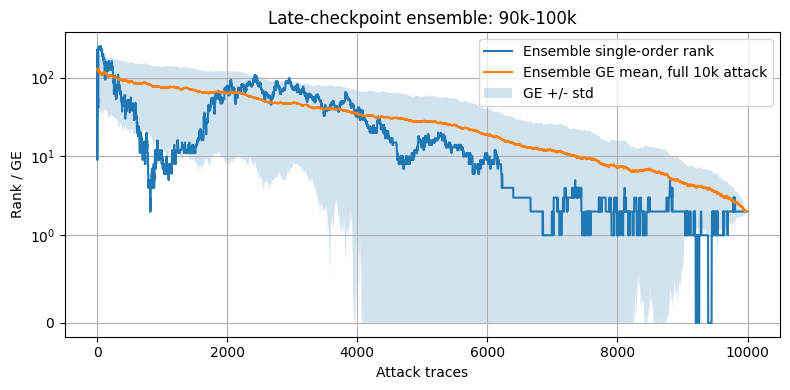

In [35]:
# ============================================================
# Late checkpoint prediction ensemble
# Optional ablation, not the clean main result.
# ============================================================

def logmeanexp_np(x, axis=0):
    m = np.max(x, axis=axis, keepdims=True)
    return np.squeeze(
        m + np.log(np.mean(np.exp(x - m), axis=axis, keepdims=True)),
        axis=axis,
    )


@torch.no_grad()
def predict_log_probs_for_checkpoint(path):
    load_checkpoint_for_eval(path)

    logits, labels = predict_logits(
        model,
        attack_loader,
        desc=f"Predict {path.name}",
    )

    return stable_log_softmax_np(logits)


ENSEMBLE_STEPS = [90000, 92000, 94000, 96000, 98000, 100000]

ensemble_paths = [
    CKPT_DIR / f"step_{s}.pt"
    for s in ENSEMBLE_STEPS
    if (CKPT_DIR / f"step_{s}.pt").exists()
]

print("Ensemble checkpoints:")
for p in ensemble_paths:
    print(" -", p.name)

log_probs_list = []

for p in ensemble_paths:
    log_probs_list.append(predict_log_probs_for_checkpoint(p))

log_probs_stack = np.stack(log_probs_list, axis=0)

ensemble_log_probs = logmeanexp_np(log_probs_stack, axis=0)

ensemble_single_curve = rank_curve_from_log_probs(
    ensemble_log_probs,
    attack_plain,
    ATTACK_TRUE_KEY,
)

ensemble_ge_mean, ensemble_ge_std, ensemble_ge_curves = guessing_entropy_from_log_probs(
    ensemble_log_probs,
    attack_plain,
    ATTACK_TRUE_KEY,
    n_traces=len(attack_plain),
    n_repeats=100,
    seed=SEED + 909,
)

ensemble_metrics = metrics_from_ge(
    ensemble_single_curve,
    ensemble_ge_mean,
)

print("Ensemble metrics:")
print(ensemble_metrics)

plt.figure(figsize=(8, 4))
plt.plot(ensemble_single_curve, label="Ensemble single-order rank")
plt.plot(ensemble_ge_mean, label="Ensemble GE mean, full 10k attack")
plt.fill_between(
    np.arange(len(ensemble_ge_mean)),
    np.maximum(ensemble_ge_mean - ensemble_ge_std, 0),
    ensemble_ge_mean + ensemble_ge_std,
    alpha=0.2,
    label="GE +/- std",
)
plt.xlabel("Attack traces")
plt.ylabel("Rank / GE")
plt.yscale("symlog", linthresh=1)
plt.title("Late-checkpoint ensemble: 90k-100k")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "ensemble_90000_100000_rank_ge.png", dpi=180)
plt.show()

In [18]:
FULL_ATTACK_TRACES = len(attack_plain)
FULL_REPEATS = 50

late_ckpt_paths = sorted(
    [
        p for p in CKPT_DIR.glob("step_*.pt")
        if checkpoint_sort_key(p) >= 50000
    ],
    key=checkpoint_sort_key,
)

full_rows = []

for p in late_ckpt_paths:
    print("\nFull-attack evaluation:", p.name)

    row, single_curve, ge_mean, ge_std, logits = evaluate_checkpoint(
        p,
        n_repeats=FULL_REPEATS,
        n_traces=FULL_ATTACK_TRACES,
    )

    full_rows.append(row)
    print(row)

full_df = pd.DataFrame(full_rows).sort_values("step")
display(full_df)

full_df.to_csv(
    RESULT_DIR / "checkpoint_full_attack_ge_sweep_from_50k.csv",
    index=False,
)

plt.figure(figsize=(8, 4))
plt.plot(full_df["step"], full_df["ge_final"], marker="o", label="Full-attack final GE")
plt.plot(full_df["step"], full_df["single_final_rank"], marker="x", label="Single final rank")
plt.axhline(1, linestyle="--", label="GE/rank 1")
plt.xlabel("Step")
plt.ylabel("Rank / GE")
plt.title("Full 10k-attack evaluation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "full_attack_ge_sweep_from_50k.png", dpi=180)
plt.show()


Full-attack evaluation: step_50000.pt


Predict step_50000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/50 [00:00<?, ?it/s]

{'checkpoint': 'step_50000.pt', 'step': 50000, 'attack_acc': 0.0044, 'single_final_rank': 13, 'single_min_rank': 1, 'single_traces_to_rank0': None, 'ge_final': 13.0, 'ge_min': 13.0, 'traces_to_ge_below_1': None}

Full-attack evaluation: step_52000.pt


Predict step_52000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

...

Predict step_56000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/50 [00:00<?, ?it/s]

{'checkpoint': 'step_56000.pt', 'step': 56000, 'attack_acc': 0.004, 'single_final_rank': 5, 'single_min_rank': 1, 'single_traces_to_rank0': None, 'ge_final': 5.0, 'ge_min': 5.0, 'traces_to_ge_below_1': None}

Full-attack evaluation: step_58000.pt


Predict step_58000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

KeyboardInterrupt: 


Evaluating: ckpt_56000
Checkpoints: ['step_56000.pt']


Predict step_56000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/50 [00:00<?, ?it/s]

{'name': 'ckpt_56000', 'single_final_rank': 5, 'single_min_rank': 1, 'single_traces_to_rank0': None, 'ge_final': 5.0, 'ge_min': 5.0, 'traces_to_ge_below_1': None}

Evaluating: ckpt_66000
Checkpoints: ['step_66000.pt']


Predict step_66000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

...

Predict step_68000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

Predict step_70000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/50 [00:00<?, ?it/s]

{'name': 'ens_56000_58000_60000_62000_64000_66000_68000_70000', 'single_final_rank': 8, 'single_min_rank': 1, 'single_traces_to_rank0': None, 'ge_final': 8.0, 'ge_min': 7.72, 'traces_to_ge_below_1': None}


,name,single_final_rank,single_min_rank,single_traces_to_rank0,ge_final,ge_min,traces_to_ge_below_1
4,ens_56000_66000_70000,4,1,NaN,4.0,4.00,None
0,ckpt_56000,5,1,NaN,5.0,5.00,None
3,ens_56000_66000,5,1,NaN,5.0,5.00,None
1,ckpt_66000,5,0,816.0,5.0,4.76,None
2,ckpt_70000,6,1,NaN,6.0,5.64,None
5,ens_56000_60000_62000_64000_66000_70000,7,1,NaN,7.0,7.00,None
6,ens_56000_58000_60000_62000_64000_66000_68000_...,8,1,NaN,8.0,7.72,None


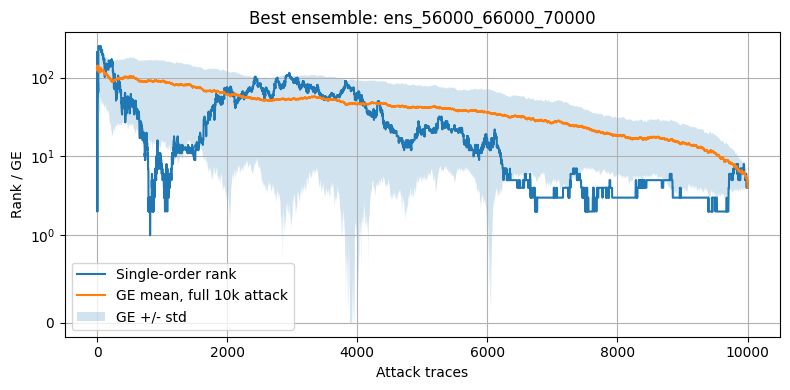

In [24]:
# ============================================================
# Late-checkpoint ensemble evaluation
# No retraining.
# ============================================================

def logmeanexp_np(x, axis=0):
    m = np.max(x, axis=axis, keepdims=True)
    return np.squeeze(
        m + np.log(np.mean(np.exp(x - m), axis=axis, keepdims=True)),
        axis=axis,
    )


def evaluate_log_probs_full_attack(log_probs, name):
    single_curve = rank_curve_from_log_probs(
        log_probs,
        attack_plain,
        ATTACK_TRUE_KEY,
    )

    ge_mean, ge_std, ge_curves = guessing_entropy_from_log_probs(
        log_probs,
        attack_plain,
        ATTACK_TRUE_KEY,
        n_traces=len(attack_plain),
        n_repeats=50,
        seed=SEED + 999,
    )

    metrics = metrics_from_ge(single_curve, ge_mean)

    row = {
        "name": name,
        **metrics,
    }

    return row, single_curve, ge_mean, ge_std


@torch.no_grad()
def predict_log_probs_for_checkpoint(path):
    load_checkpoint_for_eval(path)

    logits, labels = predict_logits(
        model,
        attack_loader,
        desc=f"Predict {path.name}",
    )

    return stable_log_softmax_np(logits)


ensemble_sets = {
    "ckpt_56000": [56000],
    "ckpt_66000": [66000],
    "ckpt_70000": [70000],

    "ens_56000_66000": [56000, 66000],
    "ens_56000_66000_70000": [56000, 66000, 70000],
    "ens_56000_60000_62000_64000_66000_70000": [56000, 60000, 62000, 64000, 66000, 70000],
    "ens_56000_58000_60000_62000_64000_66000_68000_70000": [56000, 58000, 60000, 62000, 64000, 66000, 68000, 70000],
}

ensemble_rows = []
ensemble_curves = {}

for name, steps in ensemble_sets.items():
    paths = [
        CKPT_DIR / f"step_{s}.pt"
        for s in steps
        if (CKPT_DIR / f"step_{s}.pt").exists()
    ]

    if len(paths) == 0:
        continue

    print("\n" + "=" * 80)
    print("Evaluating:", name)
    print("Checkpoints:", [p.name for p in paths])
    print("=" * 80)

    log_probs_list = []

    for path in paths:
        log_probs = predict_log_probs_for_checkpoint(path)
        log_probs_list.append(log_probs)

    log_probs_stack = np.stack(log_probs_list, axis=0)

    if len(paths) == 1:
        ensemble_log_probs = log_probs_stack[0]
    else:
        # Average probabilities, then return log-probabilities.
        ensemble_log_probs = logmeanexp_np(log_probs_stack, axis=0)

    row, single_curve, ge_mean, ge_std = evaluate_log_probs_full_attack(
        ensemble_log_probs,
        name,
    )

    ensemble_rows.append(row)
    ensemble_curves[name] = {
        "single_curve": single_curve,
        "ge_mean": ge_mean,
        "ge_std": ge_std,
        "log_probs": ensemble_log_probs,
    }

    print(row)

ensemble_df = pd.DataFrame(ensemble_rows).sort_values("ge_final")
display(ensemble_df)

ensemble_df.to_csv(
    RESULT_DIR / "late_checkpoint_ensemble_full_attack.csv",
    index=False,
)

best_ens_name = ensemble_df.iloc[0]["name"]
best_ens = ensemble_curves[best_ens_name]

plt.figure(figsize=(8, 4))
plt.plot(best_ens["single_curve"], label="Single-order rank")
plt.plot(best_ens["ge_mean"], label="GE mean, full 10k attack")
plt.fill_between(
    np.arange(len(best_ens["ge_mean"])),
    np.maximum(best_ens["ge_mean"] - best_ens["ge_std"], 0),
    best_ens["ge_mean"] + best_ens["ge_std"],
    alpha=0.2,
    label="GE +/- std",
)
plt.xlabel("Attack traces")
plt.ylabel("Rank / GE")
plt.yscale("symlog", linthresh=1)
plt.title(f"Best ensemble: {best_ens_name}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "best_late_checkpoint_ensemble_full_attack.png", dpi=180)
plt.show()

Processing: step_56000.pt


Attack step_56000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

Profile step_56000.pt:   0%|          | 0/391 [00:00<?, ?it/s]

Processing: step_66000.pt


Attack step_66000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

...

Processing: step_70000.pt


Attack step_70000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

Profile step_70000.pt:   0%|          | 0/391 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/50 [00:00<?, ?it/s]

Profile-bias-corrected ensemble metrics:
{'single_final_rank': 12, 'single_min_rank': 1, 'single_traces_to_rank0': None, 'ge_final': 12.0, 'ge_min': 11.82, 'traces_to_ge_below_1': None}


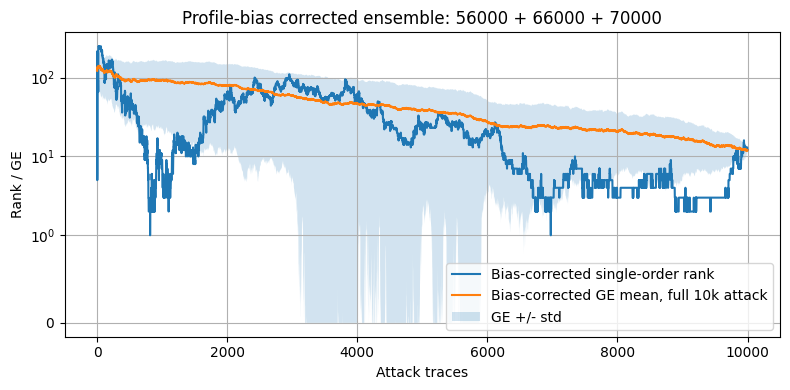

In [25]:
# ============================================================
# Profile-bias correction for best desync100 ensemble
# Uses profiling predictions to remove global class bias.
# No attack labels / no true-key information used for correction.
# ============================================================

BEST_ENSEMBLE_STEPS = [56000, 66000, 70000]


def logmeanexp_np(x, axis=0):
    m = np.max(x, axis=axis, keepdims=True)
    return np.squeeze(
        m + np.log(np.mean(np.exp(x - m), axis=axis, keepdims=True)),
        axis=axis,
    )


@torch.no_grad()
def predict_log_probs_for_loader_at_checkpoint(path, loader, desc):
    load_checkpoint_for_eval(path)

    logits, labels = predict_logits(
        model,
        loader,
        desc=desc,
    )

    return stable_log_softmax_np(logits)


# Profiling loader for estimating output class bias.
profile_eval_ds = ASCADTraceDataset(
    X_prof,
    y_prof,
    train=False,
)

profile_eval_loader = DataLoader(
    profile_eval_ds,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

attack_log_probs_list = []
profile_log_probs_list = []

for step_id in BEST_ENSEMBLE_STEPS:
    ckpt_path = CKPT_DIR / f"step_{step_id}.pt"

    if not ckpt_path.exists():
        raise FileNotFoundError(ckpt_path)

    print("Processing:", ckpt_path.name)

    attack_lp = predict_log_probs_for_loader_at_checkpoint(
        ckpt_path,
        attack_loader,
        desc=f"Attack {ckpt_path.name}",
    )

    profile_lp = predict_log_probs_for_loader_at_checkpoint(
        ckpt_path,
        profile_eval_loader,
        desc=f"Profile {ckpt_path.name}",
    )

    attack_log_probs_list.append(attack_lp)
    profile_log_probs_list.append(profile_lp)

attack_log_probs_stack = np.stack(attack_log_probs_list, axis=0)
profile_log_probs_stack = np.stack(profile_log_probs_list, axis=0)

# Ensemble probabilities, then convert back to log-probabilities.
ensemble_attack_log_probs = logmeanexp_np(attack_log_probs_stack, axis=0)
ensemble_profile_log_probs = logmeanexp_np(profile_log_probs_stack, axis=0)

# Estimate class bias from profiling predictions.
class_bias = ensemble_profile_log_probs.mean(axis=0, keepdims=True)

# Bias-corrected attack scores.
corrected_attack_log_probs = ensemble_attack_log_probs - class_bias

# Evaluate corrected scores.
corrected_single_curve = rank_curve_from_log_probs(
    corrected_attack_log_probs,
    attack_plain,
    ATTACK_TRUE_KEY,
)

corrected_ge_mean, corrected_ge_std, corrected_ge_curves = guessing_entropy_from_log_probs(
    corrected_attack_log_probs,
    attack_plain,
    ATTACK_TRUE_KEY,
    n_traces=len(attack_plain),
    n_repeats=50,
    seed=SEED + 2026,
)

corrected_metrics = metrics_from_ge(
    corrected_single_curve,
    corrected_ge_mean,
)

print("Profile-bias-corrected ensemble metrics:")
print(corrected_metrics)

plt.figure(figsize=(8, 4))
plt.plot(corrected_single_curve, label="Bias-corrected single-order rank")
plt.plot(corrected_ge_mean, label="Bias-corrected GE mean, full 10k attack")
plt.fill_between(
    np.arange(len(corrected_ge_mean)),
    np.maximum(corrected_ge_mean - corrected_ge_std, 0),
    corrected_ge_mean + corrected_ge_std,
    alpha=0.2,
    label="GE +/- std",
)
plt.xlabel("Attack traces")
plt.ylabel("Rank / GE")
plt.yscale("symlog", linthresh=1)
plt.title("Profile-bias corrected ensemble: 56000 + 66000 + 70000")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "profile_bias_corrected_ensemble_56000_66000_70000.png", dpi=180)
plt.show()